<a href="https://colab.research.google.com/github/pablo-carmonam-um-es/pcd_boletin1/blob/main/bd2_sesion3_mongo_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Bases de Datos II. NoSQL MongoDB 3

```
                                                                  ,gggggggggggg,    ,ggggggggggg,  
                                                                 dP"""88""""""Y8b, dP"""88""""""Y8,
                                                                 Yb,  88       `8b,Yb,  88      `8b
                                                                  `"  88        `8b `"  88      ,8P
                                                                      88         Y8     88aaaad8P"
  ,ggg,,ggg,,ggg,     ,ggggg,    ,ggg,,ggg,     ,gggg,gg    ,ggggg,   88         d8     88""""Y8ba
 ,8" "8P" "8P" "8,   dP"  "Y8ggg,8" "8P" "8,   dP"  "Y8I   dP"  "Y8ggg88        ,8P     88      `8b
 I8   8I   8I   8I  i8'    ,8I  I8   8I   8I  i8'    ,8I  i8'    ,8I  88       ,8P'     88      ,8P
,dP   8I   8I   Yb,,d8,   ,d8' ,dP   8I   Yb,,d8,   ,d8I ,d8,   ,d8'  88______,dP'      88_____,d8'
8P'   8I   8I   `Y8P"Y8888P"   8P'   8I   `Y8P"Y8888P"888P"Y8888P"   888888888P"       88888888P"  
                                                    ,d8I'                                          
                                                  ,dP'8I                                           
                                                 ,8"  8I                                           
                                                 I8   8I                                           
                                                 `8, ,8I                                           
                                                  `Y8P"                             
                                                  
                                                                 
                                             ______
|_  _  _  _  _     _| _     _| _ _|_ _  _     |  |
|_)(_|_> (/__>    (_|(/_   (_|(_| |_(_)_>    _|__|_
```


![MongoDB](https://webassets.mongodb.com/_com_assets/cms/MongoDB_Logo_FullColorBlack_RGB-4td3yuxzjs.png)

Esta hoja es la tercera entrega y última del trabajo con MongoDB. Veremos temas avanzados como cálculos `aggregate()` más complejos, el uso de índices, etc. Al final habrá un conjunto de ejercicios que habrá que resolver y entregar en la tarea abierta para la ocasión.

## Inicio de la hoja


In [ ]:
import sys

RunningInCOLAB: bool = 'google.colab' in sys.modules

## Instalación inicial de MongoDB (sólo necesaria en Google Colab)

In [ ]:
import subprocess
import urllib.request

if RunningInCOLAB:
  urllib.request.urlretrieve("https://raw.githubusercontent.com/dsevilla/bdge/refs/heads/25-26/addendum/mongo-utils/run-mongo-local.sh",
                             "run-mongo-local.sh")
  subprocess.run(["sh", "run-mongo-local.sh"])

## Instalación de la librería `pymongo`

In [ ]:
%pip install pymongo 'pandas[performance,parquet]'

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 24.9 MB/s eta 0:00:00


In [ ]:
from pprint import pprint as pp

import pandas as pd

Usaremos la librería `pymongo` para python. La cargamos a continuación.

In [ ]:
from pymongo import MongoClient

## Conexión a la base de datos

La conexión se inicia con `MongoClient` en el `host` descrito en el fichero `docker-compose.yml` (`mongo`), o bien a `localhost` si lo estamos haciendo en Colab.

In [ ]:
import os

db_hostname: str = "localhost" if RunningInCOLAB else os.getenv('DB_HOSTNAME', "mongo")

In [ ]:
from typing import Any

client: MongoClient[dict[str, Any]] = MongoClient(db_hostname,27017,compressors='zlib')
client

MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, compressors=['zlib'])

In [ ]:
client.list_database_names()

['admin', 'config', 'local']

Las bases de datos se crean conforme se nombran. Se puede utilizar la notación punto o la de diccionario. Las colecciones también.

In [ ]:
from pymongo.database import Database

db: Database[dict[str,Any]] = client.stackoverflow
# db: Database = client['stackoverflow'] # (equivalente)
db

Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, compressors=['zlib']), 'stackoverflow')

In [ ]:
from pymongo.collection import Collection

posts: Collection[dict[str,Any]] = db.posts
posts

Collection(Database(MongoClient(host=['localhost:27017'], document_class=dict, tz_aware=False, connect=True, compressors=['zlib']), 'stackoverflow'), 'posts')

In [ ]:
posts.count_documents({})

0

## Importación de los datos de Stackoverflow

Procedemos a importar los ficheros Parquet, pero antes ponemos el formato y significado de los campos de `Stack Overflow` para poder consultarlos si lo necesitamos.

<details><summary><b>🗂️ Formato datos Stack Overflow</b> <span style="color: #007acc;">▶️ Haz click para ver el esquema y ejemplos</span></summary>

> Notas generales
- Formato: cada fichero es XML y suele distribuirse 7zipped.
- Codificación: UTF-8. Los campos de fecha siguen el formato ISO8601: "YYYY-MM-DDTHH:mm:ss.fff".
- Nulos: cuando un campo no aplica (p.ej., `ParentId` en preguntas), no aparece o viene vacío; en nuestros Parquet suele ser `null`.
- Identificadores: `Id` es clave primaria en cada entidad. Claves foráneas enlazan por `Id` entre ficheros.

---

:file_folder: <b>badges.xml</b> (insignias logradas por usuarios)
- UserId: Id del usuario que recibe la insignia. Ej: 420. Uso: FK a `users.Id`.
- Name: Nombre de la insignia. Ej: "Teacher". Uso: clasificar tipo de logro.
- Date: Fecha de concesión. Ej: "2008-09-15T08:55:03.923". Uso: series temporales.
- Class: Categoría (1=Gold, 2=Silver, 3=Bronze). Ej: 3. Uso: nivel de la insignia.
- TagBased: Si la insignia es específica de etiqueta. Ej: true. Uso: filtrar logros por etiquetas.

---

:file_folder: <b>comments.xml</b> (comentarios en publicaciones)
- Id: Identificador del comentario. Ej: 12345. Uso: PK.
- PostId: Publicación a la que comenta. Ej: 100234. Uso: FK a `posts.Id`.
- Score: Puntuación del comentario. Ej: 5. Uso: ordenar/filtrar relevancia.
- Text: Texto del comentario. Ej: "¿Puedes compartir el error exacto?". Uso: contenido.
- CreationDate: Fecha de creación. Ej: "2008-09-06T08:07:10.730". Uso: análisis temporal.
- UserId: Autor del comentario. Ej: 314159. Uso: FK a `users.Id`.
- UserDisplayName: Nombre mostrado si el usuario fue eliminado. Ej: "user123". Uso: se usa cuando `UserId` es nulo/ausente.
- ContentLicense: Licencia del contenido. Ej: "CC BY-SA 4.0". Uso: cumplimiento/licencias.

---

:file_folder: <b>posts.xml</b> (preguntas y respuestas)
- Id: Identificador de la publicación. Ej: 98765. Uso: PK.
- PostTypeId: Tipo (1=Pregunta, 2=Respuesta). Ej: 1. Uso: rutas de procesamiento/particionado.
- ParentId: Id de la pregunta padre si es respuesta. Ej: 1234. Uso: FK a `posts.Id` (solo si `PostTypeId=2`).
- AcceptedAnswerId: Id de la respuesta aceptada (solo en preguntas). Ej: 4567. Uso: FK a `posts.Id` para marcar aceptadas.
- CreationDate: Fecha de creación. Ej: "2010-02-15T10:21:34.120". Uso: análisis temporal.
- Score: Votos netos (upvotes-downvotes). Ej: 42. Uso: ranking/calidad.
- ViewCount: Nº de vistas (solo preguntas). Ej: 12345. Uso: popularidad.
- Body: HTML/Markdown del cuerpo. Ej: "<p>¿Cómo...?</p>". Uso: contenido/NLP.
- OwnerUserId: Autor. Ej: 271828. Uso: FK a `users.Id`.
- OwnerDisplayName: Nombre mostrado si el autor fue eliminado. Ej: "John Doe". Uso: se usa cuando `OwnerUserId` es nulo (usuario eliminado o anónimo).
- LastEditorUserId: Último usuario que editó. Ej: 314159. Uso: FK a `users.Id`.
- LastEditorDisplayName: Nombre si el editor fue eliminado. Ej: "Community". Uso: solo cuando `LastEditorUserId` es nulo.
- LastEditDate: Fecha de última edición. Ej: "2009-03-05T22:28:34.823". Uso: auditoría.
- LastActivityDate: Última actividad (edición, comentario, etc.). Ej: "2009-03-11T12:51:01.480". Uso: ordenación por actividad reciente.
- CommunityOwnedDate: Fecha desde la que es de la comunidad. Ej: "2009-03-11T12:51:01.480". Uso: gobernanza.
- ClosedDate: Fecha de cierre (si procede). Ej: "2012-01-01T12:00:00.000". Uso: moderación.
- Title: Título de la pregunta. Ej: "¿Cómo unir listas en Python?". Uso: metadata/búsqueda.
- Tags: Lista de etiquetas en formato XML/HTML: "<python><list><merge>". Uso: clasificación por tema.
- AnswerCount: Nº de respuestas (en preguntas). Ej: 5. Uso: engagement.
- CommentCount: Nº de comentarios. Ej: 3. Uso: actividad.
- FavoriteCount: Favoritos marcados (legacy). Ej: 10. Uso: popularidad histórica.
- ContentLicense: Licencia. Ej: "CC BY-SA 4.0". Uso: cumplimiento.

---

:file_folder: <b>posthistory.xml</b> (historial detallado de cambios)
- Id: PK del evento de historial. Ej: 5555.
- PostHistoryTypeId: Tipo de cambio. Uso: clasifica el evento. Ejemplos:
  - 1: Initial Title – primer título de la pregunta.
  - 2: Initial Body – primer cuerpo en crudo.
  - 3: Initial Tags – primeras etiquetas.
  - 4: Edit Title – cambio de título.
  - 5: Edit Body – cambio de cuerpo (markdown crudo).
  - 6: Edit Tags – cambio de etiquetas.
  - 7/8/9: Rollback Title/Body/Tags – revertidos.
  - 10: Post Closed – cierre por votos.
  - 11: Post Reopened – reapertura.
  - 12/13: Post Deleted/Undeleted – borrado/restaurado.
  - 14/15: Post Locked/Unlocked – bloqueado/desbloqueado.
  - 16: Community Owned – pasa a comunidad.
  - 17: Post Migrated – migración (origen/destino).
  - 18: Question Merged – fusión de preguntas.
  - 19/20: Question Protected/Unprotected – protegido/desprotegido.
  - 21: Post Disassociated – se elimina el OwnerUserId.
  - 22: Question Unmerged – deshace fusión.
- PostId: Publicación afectada. Ej: 98765. Uso: FK a `posts.Id`.
- RevisionGUID: Agrupa múltiples registros de un mismo acto. Ej: "3E5B...". Uso: correlación.
- CreationDate: Fecha del evento. Ej: "2009-03-05T22:28:34.823".
- UserId: Usuario que realiza el cambio. Ej: 271828. Uso: FK a `users.Id`.
- UserDisplayName: Si el usuario fue eliminado. Ej: "user123". Uso: cuando `UserId` nulo.
- Comment: Comentario del editor. Ej: "typo fix". Uso: auditoría.
- Text: Valor crudo nuevo asociado al cambio. Ej: nuevo markdown o JSON.
  - Para tipos 10–15: JSON con usuarios que han votado esa acción de moderación.
  - Para tipo 17: Detalles de migración: "from <url>" o "to <url>".
- CloseReasonId: Motivo de cierre (histórico). Ejemplos:
  - 1: Exact Duplicate – duplicada de otra.
  - 2: off-topic – fuera de tema.
  - 3: subjective – demasiado subjetiva.
  - 4: not a real question – no es una pregunta real.
  - 7: too localized – demasiado localizada.

---

:file_folder: <b>postlinks.xml</b> (enlaces entre publicaciones)
- Id: PK del enlace. Ej: 2222.
- CreationDate: Fecha del enlace. Ej: "2011-05-05T10:00:00.000".
- PostId: Publicación origen. Ej: 1000. Uso: FK a `posts.Id`.
- RelatedPostId: Publicación destino. Ej: 1001. Uso: FK a `posts.Id`.
- PostLinkTypeId: Tipo de relación. Uso: grafo entre posts.
  - 1: Linked – relacionados.
  - 3: Duplicate – duplicados.

---

:file_folder: <b>users.xml</b> (usuarios)
- Id: PK del usuario. Ej: 271828.
- AccountId: Id de cuenta en la red Stack Exchange. Ej: 123456. Uso: consolidación multi-sitio.
- Reputation: Reputación. Ej: 15234. Uso: privilegios/ordenación.
- CreationDate: Alta del usuario. Ej: "2008-07-31T21:42:52.667".
- DisplayName: Nombre mostrado. Ej: "Jane Doe". Uso: UI.
- EmailHash: Hash MD5 de email (legacy). Ej: "fcea920f...". Uso: avatar histórico.
- LastAccessDate: Último acceso. Ej: "2020-04-01T12:00:00.000". Uso: actividad.
- WebsiteUrl: Web personal. Ej: "https://janedoe.dev".
- Location: Ubicación libre. Ej: "Madrid, ES".
- Age: Edad (cuando se compartía). Ej: 32.
- AboutMe: BIO en HTML/Markdown. Ej: "<p>Desarrollo datos...</p>".
- Views: Visitas al perfil. Ej: 1234.
- UpVotes: Upvotes emitidos por el usuario. Ej: 500.
- DownVotes: Downvotes emitidos. Ej: 20.
- ProfileImageUrl: Avatar. Ej: "https://.../image.png".

---

:file_folder: <b>votes.xml</b> (votos a publicaciones)
- Id: PK del voto. Ej: 7777.
- PostId: Publicación votada. Ej: 98765. Uso: FK a `posts.Id`.
- VoteTypeId: Tipo de voto/acción. Uso: métricas de calidad/moderación.
  - 1: AcceptedByOriginator – el autor de la pregunta acepta una respuesta (equivale a `AcceptedAnswerId`).
  - 2: UpMod – upvote.
  - 3: DownMod – downvote.
  - 4: Offensive – ofensivo (legacy).
  - 5: Favorite – marcado como favorito (legacy); si `VoteTypeId=5`, `UserId` se rellena.
  - 6: Close – voto de cierre.
  - 7: Reopen – voto de reapertura.
  - 8: BountyStart – inicio de recompensa.
  - 9: BountyClose – cierre de recompensa; si `VoteTypeId=9`, `BountyAmount` se rellena.
  - 10: Deletion – voto de borrado.
  - 11: Undeletion – voto de restauración.
  - 12: Spam – marcado como spam.
  - 13: InformModerator – informar a moderación.
- CreationDate: Fecha del voto. Ej: "2015-06-10T09:30:00.000".
- UserId: Usuario que vota (solo para algunos tipos como 5). Ej: 54321. Uso: FK a `users.Id`.
- BountyAmount: Cantidad de recompensa (solo tipo 9). Ej: 100.

---

:file_folder: <b>tags.xml</b> (etiquetas del sitio)
- Id: PK de la etiqueta. Ej: 42.
- TagName: Nombre de la etiqueta. Ej: "python". Uso: clasificación temática.
- Count: Nº de usos en preguntas. Ej: 150234. Uso: popularidad.
- ExcerptPostId: Id del post con el extracto de la wiki de etiqueta. Ej: 123. Uso: FK a `posts.Id`.
- WikiPostId: Id del post con el artículo de la wiki de etiqueta. Ej: 124. Uso: FK a `posts.Id`.

</details>

Importamos los ficheros Parquet, primero definiendo las funciones que se necesitan, y después ejecutándolas.

In [ ]:
from asyncio import Queue, Task, create_task, to_thread

from pandas import DataFrame


def load_dataframe(parquetfile: str, logqueue: Queue[str] | None = None) -> DataFrame:
    BASE_URL: str = "https://github.com/dsevilla/bd2-data/releases/download/parquet-files-25-26/"
    try:
        df: DataFrame = pd.read_parquet(f"{BASE_URL}/{parquetfile}")
        logqueue.put_nowait(f"Loaded {len(df)} rows from dataframe.") if logqueue else None

        return df.replace({pd.NaT: None})

    except Exception as e:
        logqueue.put_nowait(f"Error loading Dataframe: {e}.") if logqueue else None
        raise e

In [ ]:
from pymongo.results import InsertManyResult


def insert_dataframe_into_mongo(
    collection: Collection, df: DataFrame, logqueue: Queue | None = None
) -> InsertManyResult:
    result: InsertManyResult = collection.insert_many(
        df.to_dict("records"), ordered=False, bypass_document_validation=True
    )
    logqueue.put_nowait(f"Inserted {len(df)} records into MongoDB.") if logqueue else None
    return result


def load_parquet_into_mongo(
    collection: Collection,
    parquetfile: str,
    logqueue: Queue[str] | None = None,
) -> InsertManyResult:
    df: DataFrame = load_dataframe(parquetfile, logqueue)
    try:
        return insert_dataframe_into_mongo(collection, df, logqueue)
    except Exception as e:
        logqueue.put_nowait(f"Error inserting DataFrame into MongoDB: {e}.") if logqueue else None
        raise e
    finally:
        del df  # Free memory

Importación de los ficheros Parquet. Por ahora creamos una colección diferente para cada uno. Después estudiaremos cómo poder optimizar el acceso usando agregación.

Creamos un índice para el campo '`Id`' en la colección de tags.

In [ ]:
tags_collection: Collection[dict[str, Any]] = db["tags"]
tags_collection.create_index([("Id", 1)], unique=True)

'Id_1'

Se crea una cola de mensajes (`Queue`) para que los procesos en segundo plano puedan ir mostrando el progreso de la importación. En cualquier momento se puede leer mensajes de esa cola (si están disponibles) y podemos ver si se ha producido algún error o si se ha terminado de procesar los elementos.

La importación de los *Tags* se realiza en primer plano porque es pequeña. El resto de colecciones las importaremos en segundo plano (con un hilo o *thread*).

In [ ]:
# No añadir datos si ya existe la colección
existing_tags_count: int = tags_collection.count_documents({})
if existing_tags_count > 0:
    print("La colección Tags ya existe. No se realiza la importación. Elimínala con drop().")
else:
    insert_tags_queue: Queue[str] = Queue()
    load_parquet_into_mongo(tags_collection, "Tags.parquet", insert_tags_queue)
    while not insert_tags_queue.empty():
        log_message: str = await insert_tags_queue.get()
        print(log_message)

Loaded 3048 rows from dataframe.
Inserted 3048 records into MongoDB.


In [ ]:
tags_collection.find_one()

{'_id': ObjectId('69ad504407f593c38357d780'),
 'Id': 1,
 'Count': 1472,
 'ExcerptPostId': 680,
 'TagName': '.net',
 'WikiPostId': 679}

Importamos los datos de Stackoverflow. Lo haremos en paralelo con todas las colecciones restantes:

In [ ]:
users_collection: Collection[dict[str, Any]] = db["users"]

users_load_task: Task[InsertManyResult] = create_task(
    to_thread(load_parquet_into_mongo, users_collection, "Users.parquet")
)

In [ ]:
posts_collection: Collection[dict[str, Any]] = db["posts"]
posts_collection.create_index([("Id", 1)], unique=True)

posts_load_queue: Queue[str] = Queue()
posts_load_task: Task[InsertManyResult] = create_task(
    to_thread(load_parquet_into_mongo, posts_collection, "Posts.parquet", posts_load_queue)
)

In [ ]:
comments_collection: Collection[dict[str, Any]] = db["comments"]

comments_load_queue: Queue[str] = Queue()
comments_load_task: Task[InsertManyResult] = create_task(
    to_thread(load_parquet_into_mongo, comments_collection, "Comments.parquet", comments_load_queue)
)

In [ ]:
votes_collection: Collection[dict[str, Any]] = db["votes"]
votes_collection.create_index([("Id", 1)], unique=True)

votes_load_queue: Queue[str] = Queue()
votes_load_task: Task[InsertManyResult] = create_task(
    to_thread(load_parquet_into_mongo, votes_collection, "Votes.parquet", votes_load_queue)
)

In [ ]:
print(f"Post loading done: {posts_load_task.done()}.")
while not posts_load_queue.empty():
    log_message: str = posts_load_queue.get_nowait()
    print(log_message)

Post loading done: False.


In [ ]:
users_load_task.done()

False

In [ ]:
comments_load_task.done()

False

In [ ]:
votes_load_task.done()

False

### El API de colección de MongoDB

El API de colección en Python se puede encontrar aquí: https://docs.mongodb.com/drivers/pymongo/. La mayoría de libros y referencias muestran el uso de mongo desde Javascript, ya que el *shell* de MongoDB acepta ese lenguaje. La sintaxis con respecto a Python cambia un poco, y se puede seguir en el enlace anterior. Existe incluso un curso de la MongoDB University que se puede realizar de forma gratuita: https://learn.mongodb.com/learning-paths/using-mongodb-with-python

## Framework de Agregación

Framework de agregación:
- Aquí está la referencia de las diferentes etapas por las que puede pasar un pipeline: https://www.mongodb.com/docs/manual/reference/operator/aggregation-pipeline/.
- Y aquí los distintos operadores que se permiten dentro de las etapas: https://docs.mongodb.com/manual/reference/operator/aggregation/.
- Y aquí incluso un libro completo con usos prácticos de ejecutar agregación: https://www.practical-mongodb-aggregations.com/.

A continuación otro vídeo interesante:

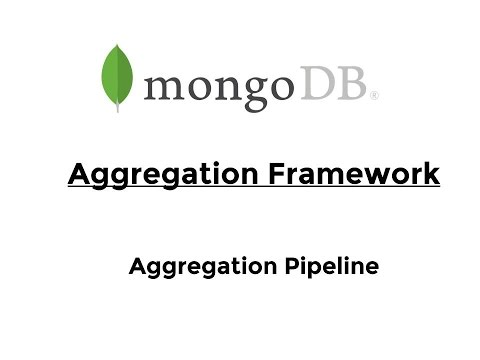

In [ ]:
from IPython.display import YouTubeVideo

YouTubeVideo('VSX4a3h4SmQ',width=600)

![](https://miro.medium.com/max/1060/1*2lDBxvZ8Cr3JYkoODTa0lQ.png)

### Esperamos a que todo se haya cargado para poder continuar

In [ ]:
import asyncio

await asyncio.gather(
    users_load_task,
    posts_load_task,
    comments_load_task,
    votes_load_task
);

**Proyección**: el operador `$project` permite filtrar qué campos de los documentos queremos usar en las siguientes fases de agregación.

In [ ]:
from pymongo.command_cursor import CommandCursor

respuestas: CommandCursor[dict[str,Any]] = db['posts'].aggregate( [
    {'$project' : { 'Id' : True }},
    {'$limit': 20} ])
pp(list(respuestas))

[{'Id': 1, '_id': ObjectId('69ad508b07f593c383734e70')},
 {'Id': 2, '_id': ObjectId('69ad508b07f593c383734e71')},
 {'Id': 3, '_id': ObjectId('69ad508b07f593c383734e72')},
 {'Id': 4, '_id': ObjectId('69ad508b07f593c383734e73')},
 {'Id': 5, '_id': ObjectId('69ad508b07f593c383734e74')},
 {'Id': 6, '_id': ObjectId('69ad508b07f593c383734e75')},
 {'Id': 7, '_id': ObjectId('69ad508b07f593c383734e76')},
 {'Id': 8, '_id': ObjectId('69ad508b07f593c383734e77')},
 {'Id': 9, '_id': ObjectId('69ad508b07f593c383734e78')},
 {'Id': 10, '_id': ObjectId('69ad508b07f593c383734e79')},
 {'Id': 11, '_id': ObjectId('69ad508b07f593c383734e7a')},
 {'Id': 12, '_id': ObjectId('69ad508b07f593c383734e7b')},
 {'Id': 14, '_id': ObjectId('69ad508b07f593c383734e7c')},
 {'Id': 15, '_id': ObjectId('69ad508b07f593c383734e7d')},
 {'Id': 16, '_id': ObjectId('69ad508b07f593c383734e7e')},
 {'Id': 17, '_id': ObjectId('69ad508b07f593c383734e7f')},
 {'Id': 18, '_id': ObjectId('69ad508b07f593c383734e80')},
 {'Id': 19, '_id': Obje

_Lookup_! El operador `$lookup` permite realizar búsquedas en otras colecciones. Podrían interpretarse como un `join` en el modelo relacional.

El `$lookup` genera un _array_ con todos los resultados. El operador `$arrayElementAt` accede al primer elemento.

In [ ]:
respuestas: CommandCursor[dict[str,Any]] = db.posts.aggregate( [
        {'$match': { 'Score' : {'$gte': 150}}},
        {'$lookup': {
            'from': "users",
            'localField': "OwnerUserId",
            'foreignField': "Id",
            'as': "owner"}
        },
        { '$project' : {
            'Id' : True,
            'Score' : True,
            'username' : {'$arrayElemAt' : ['$owner.DisplayName', 0]},
            'owner.DisplayName' : True
          }}
        ])
pp(list(respuestas))

[{'Id': 40,
  'Score': 206,
  '_id': ObjectId('69ad508b07f593c383734e94'),
  'owner': [{'DisplayName': 'jachguate'}],
  'username': 'jachguate'},
 {'Id': 197,
  'Score': 176,
  '_id': ObjectId('69ad508b07f593c383734f14'),
  'owner': [{'DisplayName': 'Peter Olson'}],
  'username': 'Peter Olson'},
 {'Id': 204,
  'Score': 195,
  '_id': ObjectId('69ad508b07f593c383734f18'),
  'owner': [{'DisplayName': 'Konamiman'}],
  'username': 'Konamiman'},
 {'Id': 18232,
  'Score': 232,
  '_id': ObjectId('69ad508b07f593c3837386e2'),
  'owner': [{'DisplayName': 'Alvaro Montoro'}],
  'username': 'Alvaro Montoro'},
 {'Id': 18233,
  'Score': 219,
  '_id': ObjectId('69ad508b07f593c3837386e3'),
  'owner': [{'DisplayName': 'Alvaro Montoro'}],
  'username': 'Alvaro Montoro'},
 {'Id': 87842,
  'Score': 173,
  '_id': ObjectId('69ad508c07f593c383744f99'),
  'owner': [{'DisplayName': 'Alvaro Montoro'}],
  'username': 'Alvaro Montoro'}]


`$unwind` también puede usarse. "Desdobla" cada fila por cada elemento del array. En este caso, como sabemos que el array sólo contiene un elemento, sólo habrá una fila por fila original, pero sin el _array_. Finalmente se puede proyectar el campo que se quiera. Volvemos a proyectar los campos anteriores para comprobar las diferencias.

In [ ]:
respuestas: CommandCursor[dict[str,Any]] = db.posts.aggregate( [
        { '$match': { 'Score' : {'$gte': 150}}},
        { '$lookup': {
            'from': "users",
            'localField': "OwnerUserId",
            'foreignField': "Id",
            'as': "owner"
          }
        },
        { '$unwind': '$owner'},
        { '$project' : {
            'Id' : True,
            'Score' : True,
            'username': '$owner.DisplayName',
            'owner.DisplayName' : True
          }
        }
        ])
pp(list(respuestas))

[{'Id': 40,
  'Score': 206,
  '_id': ObjectId('69ad508b07f593c383734e94'),
  'owner': {'DisplayName': 'jachguate'},
  'username': 'jachguate'},
 {'Id': 197,
  'Score': 176,
  '_id': ObjectId('69ad508b07f593c383734f14'),
  'owner': {'DisplayName': 'Peter Olson'},
  'username': 'Peter Olson'},
 {'Id': 204,
  'Score': 195,
  '_id': ObjectId('69ad508b07f593c383734f18'),
  'owner': {'DisplayName': 'Konamiman'},
  'username': 'Konamiman'},
 {'Id': 18232,
  'Score': 232,
  '_id': ObjectId('69ad508b07f593c3837386e2'),
  'owner': {'DisplayName': 'Alvaro Montoro'},
  'username': 'Alvaro Montoro'},
 {'Id': 18233,
  'Score': 219,
  '_id': ObjectId('69ad508b07f593c3837386e3'),
  'owner': {'DisplayName': 'Alvaro Montoro'},
  'username': 'Alvaro Montoro'},
 {'Id': 87842,
  'Score': 173,
  '_id': ObjectId('69ad508c07f593c383744f99'),
  'owner': {'DisplayName': 'Alvaro Montoro'},
  'username': 'Alvaro Montoro'}]


Repetimos la consulta anterior, pero proyectando solamente el campo 'username'.

In [ ]:
respuestas: CommandCursor[dict[str,Any]] = db.posts.aggregate( [
        { '$match': { 'Score' : {'$gte': 150}}},
        { '$lookup': {
            'from': "users",
            'localField': "OwnerUserId",
            'foreignField': "Id",
            'as': "owner"
          }
        },
        { '$unwind': '$owner'},
        { '$project' : {
            'username': '$owner.DisplayName',
          }
        }
        ])
pp(list(respuestas))

[{'_id': ObjectId('69ad508b07f593c383734e94'), 'username': 'jachguate'},
 {'_id': ObjectId('69ad508b07f593c383734f14'), 'username': 'Peter Olson'},
 {'_id': ObjectId('69ad508b07f593c383734f18'), 'username': 'Konamiman'},
 {'_id': ObjectId('69ad508b07f593c3837386e2'), 'username': 'Alvaro Montoro'},
 {'_id': ObjectId('69ad508b07f593c3837386e3'), 'username': 'Alvaro Montoro'},
 {'_id': ObjectId('69ad508c07f593c383744f99'), 'username': 'Alvaro Montoro'}]


Veamos cómo se ha realizado la consulta anterior. Para ello usamos la opción `explain`. En el campo `strategy` que se ha usado `NestedLoopJoin`. Para cada documento en `posts`, busca ''manualmente'' en `users` los documentos que coincidan con `OwnerUserId`.

In [ ]:
db.command('aggregate', 'posts', pipeline= [
  { '$match': { 'Score' : {'$gte': 150}}},
  { '$lookup': {
      'from': "users",
      'localField': "OwnerUserId",
      'foreignField': "Id",
      'as': "owner"
    }
  },
  { '$unwind': '$owner'},
  { '$project': {
      'username': '$owner.DisplayName'
     }
  }
  ],
  explain = True
)

{'explainVersion': '1',
 'stages': [{'$cursor': {'queryPlanner': {'namespace': 'stackoverflow.posts',
     'parsedQuery': {'Score': {'$gte': 150}},
     'indexFilterSet': False,
     'queryHash': 'FE018D7F',
     'planCacheShapeHash': 'FE018D7F',
     'planCacheKey': '632B2F53',
     'optimizationTimeMillis': 0,
     'maxIndexedOrSolutionsReached': False,
     'maxIndexedAndSolutionsReached': False,
     'maxScansToExplodeReached': False,
     'prunedSimilarIndexes': False,
     'winningPlan': {'isCached': False,
      'stage': 'PROJECTION_SIMPLE',
      'transformBy': {'OwnerUserId': 1, '_id': 1},
      'inputStage': {'stage': 'COLLSCAN',
       'filter': {'Score': {'$gte': 150}},
       'direction': 'forward'}},
     'rejectedPlans': []}}},
  {'$lookup': {'from': 'users',
    'as': 'owner',
    'localField': 'OwnerUserId',
    'foreignField': 'Id',
    'unwinding': {'preserveNullAndEmptyArrays': False}}},
  {'$project': {'_id': True, 'username': '$owner.DisplayName'}}],
 'queryShapeH

## Definición de índices

Las consultas anteriores pueden ser **muy lentas** si no existen los índices adecuados, ya que el uso de `$lookup` (equivalente a un JOIN de SQL) hace que se tenga que buscar en toda la colección usuarios para encontrar el usuario con `Id` especificado por `OwnerUserId`. Vamos a crear un índice para acelerar estas consultas.

También, como veíamos antes, el primer paso en la consulta incluía un "`COLLSCAN`" de la colección `posts`, lo que también es muy lento. Para acelerar esta parte, vamos a crear un índice para el campo `Score` de la colección `posts`, que es el campo por el que se filtra. Este índice va a ser ordenado, ya que se hacen búsquedas por un rango de valores (mayores que 150).

In [ ]:
from pymongo import HASHED

(db.users.create_index([('Id', HASHED)], name='Id_hashed_index'),
 db.posts.create_index([('Score', 1)], name='Score_index'))

('Id_hashed_index', 'Score_index')

In [ ]:
# Verificar que los índices se han creado correctamente
print("Índices creados:")
print(f"posts collection indexes: {list(db.posts.list_indexes())}")

Índices creados:
posts collection indexes: [SON([('v', 2), ('key', SON([('_id', 1)])), ('name', '_id_')]), SON([('v', 2), ('key', SON([('Id', 1)])), ('name', 'Id_1'), ('unique', True)]), SON([('v', 2), ('key', SON([('Score', 1)])), ('name', 'Score_index')])]


In [ ]:
respuestas: CommandCursor[dict[str,Any]] = db.posts.aggregate( [
  { '$match': { 'Score' : {'$gte': 150}}},
  { '$lookup': {
      'from': "users",
      'localField': "OwnerUserId",
      'foreignField': "Id",
      'as': "owner"
    }
  },
  { '$unwind': '$owner'},
  { '$project' : {
        'username': '$owner.DisplayName'
    }
  }
  ])
pp(list(respuestas))

[{'_id': ObjectId('69ad508c07f593c383744f99'), 'username': 'Alvaro Montoro'},
 {'_id': ObjectId('69ad508b07f593c383734f14'), 'username': 'Peter Olson'},
 {'_id': ObjectId('69ad508b07f593c383734f18'), 'username': 'Konamiman'},
 {'_id': ObjectId('69ad508b07f593c383734e94'), 'username': 'jachguate'},
 {'_id': ObjectId('69ad508b07f593c3837386e3'), 'username': 'Alvaro Montoro'},
 {'_id': ObjectId('69ad508b07f593c3837386e2'), 'username': 'Alvaro Montoro'}]


Veamos cómo se ha usado el índice en la consulta (no se incluye la consulta entera porque el explain no lo termina de hacer bien si hay muchos pasos). De nuevo usamos la opción `explain`. En el campo `strategy` que se ha usado `IndexedLoopJoin`. En este caso se utiliza el índice creado en `users` para hacer la búsqueda de una forma más rápida y eficiente.

También se usa el índice creado en `posts` para filtrar por `Score` de una forma más rápida.

In [ ]:
db.command('aggregate', 'posts', pipeline= [
  { '$match': { 'Score' : {'$gte': 150}}},
  { '$lookup': {
      'from': "users",
      'localField': "OwnerUserId",
      'foreignField': "Id",
      'as': "owner"
    }
  }],
  explain = True
)

{'explainVersion': '2',
 'queryPlanner': {'namespace': 'stackoverflow.posts',
  'parsedQuery': {'Score': {'$gte': 150}},
  'indexFilterSet': False,
  'queryHash': '0873BBE5',
  'planCacheShapeHash': '0873BBE5',
  'planCacheKey': '5F4A4C1A',
  'optimizationTimeMillis': 0,
  'optimizedPipeline': True,
  'maxIndexedOrSolutionsReached': False,
  'maxIndexedAndSolutionsReached': False,
  'maxScansToExplodeReached': False,
  'prunedSimilarIndexes': False,
  'winningPlan': {'isCached': False,
   'queryPlan': {'stage': 'EQ_LOOKUP',
    'planNodeId': 3,
    'foreignCollection': 'stackoverflow.users',
    'localField': 'OwnerUserId',
    'foreignField': 'Id',
    'asField': 'owner',
    'strategy': 'IndexedLoopJoin',
    'indexName': 'Id_hashed_index',
    'indexKeyPattern': {'Id': 'hashed'},
    'scanDirection': 'forward',
    'inputStage': {'stage': 'FETCH',
     'planNodeId': 2,
     'inputStage': {'stage': 'IXSCAN',
      'planNodeId': 1,
      'keyPattern': {'Score': 1},
      'indexName': 

### Operador `$group`

El operador [`$group`](https://www.mongodb.com/docs/manual/reference/operator/aggregation/group/) agrupa los documentos por una clave especificada en `_id` y permite calcular valores acumulados sobre cada grupo usando operadores como `$sum`, `$avg`, `$min`, `$max`, `$push`, `$addToSet`, etc. Es el equivalente al `GROUP BY` de SQL.

Calculemos la media de puntuación por usuario:

In [ ]:
media_puntuación_usuarios: CommandCursor[dict[str,Any]] = db.posts.aggregate([
    {
        '$group': {
            '_id': '$OwnerUserId',
            'media_puntuación': { '$avg':  '$Score' }
            }
    },
    { '$limit': 100 }
    ])
pp(list(media_puntuación_usuarios))

[{'_id': 45449, 'media_puntuación': 0.0},
 {'_id': 50330, 'media_puntuación': 0.9},
 {'_id': 213489, 'media_puntuación': 0.0},
 {'_id': 226262, 'media_puntuación': 0.0},
 {'_id': 9958, 'media_puntuación': 3.793103448275862},
 {'_id': 30962, 'media_puntuación': 2.0},
 {'_id': 215855, 'media_puntuación': 0.0},
 {'_id': 23443, 'media_puntuación': 0.7777777777777778},
 {'_id': 182571, 'media_puntuación': 0.0},
 {'_id': 44398, 'media_puntuación': 0.0},
 {'_id': 155984, 'media_puntuación': 0.8},
 {'_id': 39020, 'media_puntuación': 1.1875},
 {'_id': 201881, 'media_puntuación': -0.5},
 {'_id': 122045, 'media_puntuación': 1.0},
 {'_id': 95596, 'media_puntuación': 1.0},
 {'_id': 116370, 'media_puntuación': 0.0},
 {'_id': 106028, 'media_puntuación': 0.5982142857142857},
 {'_id': 159278, 'media_puntuación': 0.0},
 {'_id': 62884, 'media_puntuación': 0.0},
 {'_id': 34812, 'media_puntuación': 0.8108108108108109},
 {'_id': 227175, 'media_puntuación': 0.0},
 {'_id': 106904, 'media_puntuación': 0.0},
 {

Calculemos el máximo y mínimo de puntuación de cada usuario:

In [ ]:
max_min_puntuación_usuarios: CommandCursor[dict[str,Any]] = db.posts.aggregate([
    {
        '$group': {
            '_id': '$OwnerUserId',
            'media_puntuación': { '$avg':  '$Score' },
            'min': { '$min':  '$Score' },
            'max': { '$max' : "$Score"}
        }
    },
    { '$limit': 100 }
    ])
pp(list(max_min_puntuación_usuarios))

[{'_id': 45449, 'max': 0, 'media_puntuación': 0.0, 'min': 0},
 {'_id': 50330, 'max': 3, 'media_puntuación': 0.9, 'min': 0},
 {'_id': 213489, 'max': 0, 'media_puntuación': 0.0, 'min': 0},
 {'_id': 226262, 'max': 0, 'media_puntuación': 0.0, 'min': 0},
 {'_id': 9958, 'max': 37, 'media_puntuación': 3.793103448275862, 'min': 0},
 {'_id': 30962, 'max': 2, 'media_puntuación': 2.0, 'min': 2},
 {'_id': 215855, 'max': 0, 'media_puntuación': 0.0, 'min': 0},
 {'_id': 23443, 'max': 2, 'media_puntuación': 0.7777777777777778, 'min': 0},
 {'_id': 182571, 'max': 0, 'media_puntuación': 0.0, 'min': 0},
 {'_id': 44398, 'max': 0, 'media_puntuación': 0.0, 'min': 0},
 {'_id': 155984, 'max': 2, 'media_puntuación': 0.8, 'min': 0},
 {'_id': 39020, 'max': 3, 'media_puntuación': 1.1875, 'min': 0},
 {'_id': 201881, 'max': 0, 'media_puntuación': -0.5, 'min': -1},
 {'_id': 122045, 'max': 1, 'media_puntuación': 1.0, 'min': 1},
 {'_id': 95596, 'max': 2, 'media_puntuación': 1.0, 'min': 0},
 {'_id': 116370, 'max': 0, 'm

Pasemos ahora a trabajar con la colección Votes. Antes de empezar, veamos un ejemplo de un voto:

In [ ]:
db.votes.find_one()

{'_id': ObjectId('69ad506207f593c38357e368'),
 'Id': 1,
 'BountyAmount': 0,
 'CreationDate': datetime.datetime(2015, 10, 29, 0, 0),
 'PostId': 1,
 'UserId': None,
 'VoteTypeId': 2}

### Operador `$cond` y comprobación de votos

Podemos comprobar que todos los posts tienen los votos correctos contando los votos positivos (`VoteTypeId=2`) y negativos (`VoteTypeId=3`).

Primero, calcular el resultado de cada voto. Nótese cómo haciendo uso de [`$cond`](https://www.mongodb.com/docs/manual/reference/operator/aggregation/cond/) se puede aplicar una condición `if`/`then`/`else` para sumar o restar dependiendo del tipo del voto. `$cond` evalúa una expresión booleana y devuelve un valor u otro en función del resultado, similar a un operador ternario.

Después lo comprobaremos con los existentes en Posts.

In [ ]:
score_by_post: CommandCursor[dict[str,Any]] = db.votes.aggregate([
    { "$match" : {"$or" : [ {"VoteTypeId" : 2},
                            {"VoteTypeId" : 3}]
                  }
    },
    {
        '$group': {
            '_id': '$PostId',
            'score': { '$sum': { "$cond": {
                                            "if" : { "$eq" : [ "$VoteTypeId", 2 ]},
                                            "then" : 1,
                                            "else" : -1
                                          }} }
        }
    },
    { '$limit' : 20}
    ])
pp(list(score_by_post))

[{'_id': 287368, 'score': 1},
 {'_id': 535607, 'score': -4},
 {'_id': 69121, 'score': 1},
 {'_id': 463906, 'score': 1},
 {'_id': 558324, 'score': 4},
 {'_id': 106690, 'score': 4},
 {'_id': 104399, 'score': -1},
 {'_id': 201130, 'score': 0},
 {'_id': 414891, 'score': 1},
 {'_id': 520315, 'score': 1},
 {'_id': 103418, 'score': -1},
 {'_id': 31415, 'score': 2},
 {'_id': 59298, 'score': 1},
 {'_id': 343639, 'score': -2},
 {'_id': 326509, 'score': 1},
 {'_id': 93688, 'score': 3},
 {'_id': 206480, 'score': -1},
 {'_id': 120527, 'score': -1},
 {'_id': 386072, 'score': 3},
 {'_id': 174894, 'score': 1}]


Y después comparado con lo que hay en los Posts. La consulta, como se puede ver, sacará sólo los elementos en donde los votos en `Votes` no coincide con `Posts` (debe ser vacío). Nótese el uso de [`$expr`](https://www.mongodb.com/docs/manual/reference/operator/query/expr/), que permite usar expresiones de agregación dentro de un `$match`. Sin `$expr`, no se podrían comparar dos campos del mismo documento entre sí dentro de un `$match`.

**CUIDADO** Si no se define el índice correcto, la consulta tarda mucho. ¿Cuál?

In [ ]:
# Creación del índice secreto... ¿cuál?
import zlib

secret_code = b'x\x9cKI\xd2+\xc8/.)\xd6K.JM,I\x8d\xcf\xccKI\xad\xd0\x88V\xf7LQ\xd7Q\xf0p\x0c\xf6pu\x89\xd5\x04\x00\xfe`\x0cD'
eval(zlib.decompress(secret_code).decode());

In [ ]:
score_by_post_comp: CommandCursor[dict[str,Any]] = db.votes.aggregate([
    {   "$match" : { 'VoteTypeId' : {'$in' : [2,3] } } },
    {
        # Como 2 y 3 son primos, sabiendo el número de elementos se puede calcular
        # 2 = v+
        # 3 = v-
        # score = 2 * v+ + 3* v-
        # count = v+ + v-
        # v- = score - 2 * count
        # v+ = 3 * count - score
        # score_final = v+ - v- = 3*count - score - score + 2*count = 5 * count - 2 * score
        '$group': {
            '_id': '$PostId',
            'score': { '$sum': "$VoteTypeId" },
            'count': { '$sum' : 1}
        }
    },
    {
        "$lookup": {
            'from': "posts",
            'localField': "_id",
            'foreignField': "Id",
            'as': "post"
        }
    },
    {   "$unwind" : "$post"},
    {   "$project" : {
            'score_final': {"$expr": {"$subtract" : [ {"$multiply" : [ 5, "$count"]},
                                                      {"$multiply" : [ 2, "$score"]}
                                                     ]
                                     }
                            },
            'post.Score': True,
         }
    },
    {
        "$match" : { '$expr': {'$ne': [ '$score_final', '$post.Score'] } }
    }
])
pp(list(score_by_post_comp))

[]


### Ejemplo de realización de una consulta de reciprocidad

Como ejemplo de consulta compleja con el Framework de Agregación, adjunto una posible solución a la consulta siguiente: ¿Hay usuarios que hacen preguntas y son respondidos por otros usuarios que a su vez preguntaron y fueron respondidos por los primeros? (Es decir, ¿hay reciprocidad en las interacciones en StackOverflow español?)

In [ ]:
RQ4: CommandCursor[dict[str,Any]] = db.posts.aggregate( [
        { "$match" : {"PostTypeId": 2}},
        { '$lookup': {
            'from': "posts",
            'localField': "ParentId",
            'foreignField': "Id",
            'as': "question"
          }
        },
        { '$unwind' : '$question' },
        { '$project' : {
            'OwnerUserId': True,
            'OP' : '$question.OwnerUserId'
          }
        },
        { '$group' : {'_id' : {'min' : { '$min' : ['$OwnerUserId' , '$OP'] },
                               'max' : { '$max' : ['$OwnerUserId' , '$OP'] }},
                      'pairs' : {'$addToSet' : { '0q': '$OP', '1a': '$OwnerUserId'}}
          }
        },
        { '$project': {
            'pairs' : True,
            'npairs' : { '$size' : '$pairs'}
          }
        },
        { '$match' : { 'npairs' : { '$eq' : 2}} }
    ])
pp(list(RQ4))

[{'_id': {'max': 69620, 'min': 69620},
  'npairs': 2,
  'pairs': [{'0q': 69620, '1a': None}, {'0q': 69620, '1a': 69620}]},
 {'_id': {'max': 25413, 'min': 25413},
  'npairs': 2,
  'pairs': [{'0q': 25413, '1a': 25413}, {'0q': 25413, '1a': None}]},
 {'_id': {'max': 54039, 'min': 54039},
  'npairs': 2,
  'pairs': [{'0q': None, '1a': 54039}, {'0q': 54039, '1a': 54039}]},
 {'_id': {'max': 18597, 'min': 250},
  'npairs': 2,
  'pairs': [{'0q': 18597, '1a': 250}, {'0q': 250, '1a': 18597}]},
 {'_id': {'max': 65107, 'min': 65107},
  'npairs': 2,
  'pairs': [{'0q': None, '1a': 65107}, {'0q': 65107, '1a': 65107}]},
 {'_id': {'max': 114296, 'min': 114296},
  'npairs': 2,
  'pairs': [{'0q': 114296, '1a': 114296}, {'0q': 114296, '1a': None}]},
 {'_id': {'max': 69228, 'min': 69228},
  'npairs': 2,
  'pairs': [{'0q': None, '1a': 69228}, {'0q': 69228, '1a': 69228}]},
 {'_id': {'max': 77372, 'min': 77372},
  'npairs': 2,
  'pairs': [{'0q': None, '1a': 77372}, {'0q': 77372, '1a': 77372}]},
 {'_id': {'max':

En el caso de que queramos tener como referencia las preguntas y respuestas a las que se refiere la conversación, se puede añadir un campo más que guarde todas las preguntas junto con sus respuestas consideradas:

In [ ]:
RQ4: CommandCursor[dict[str,Any]] = db.posts.aggregate( [
        { '$match': { 'PostTypeId' : 2}},
        { '$lookup': {
            'from': "posts",
            'localField': "ParentId",
            'foreignField': "Id",
            'as': "question"
          }
        },

        { '$unwind' : '$question' },

        { '$project' : {
            'OwnerUserId': True,
            'QId' : '$question.Id',
            'AId' : '$Id',
            'OP' : '$question.OwnerUserId'
          }
        },
        { '$group' : {'_id' : {'min' : { '$min' : ['$OwnerUserId' , '$OP'] },
                               'max' : { '$max' : ['$OwnerUserId' , '$OP'] }},
                      'pairs' : {'$addToSet' : { '0q':'$OP', '1a': '$OwnerUserId'}},
                      'considered_pairs' : { '$push' : {'QId' : '$QId', 'AId' : '$AId'}}
          }
        },
        { '$project': {
            'pairs' : True,
            'npairs' : { '$size' : '$pairs'},
            'considered_pairs' : True
          }
        },
        { '$match' : { 'npairs' : { '$eq' : 2}} }
    ])
pp(list(RQ4))

Se han truncado las últimas 5000 líneas del flujo de salida.
  'considered_pairs': [{'AId': 168324, 'QId': 168311},
                       {'AId': 183782, 'QId': 183770},
                       {'AId': 238901, 'QId': 238882},
                       {'AId': 240264, 'QId': 240241}],
  'npairs': 2,
  'pairs': [{'0q': 58179, '1a': None}, {'0q': 58179, '1a': 58179}]},
 {'_id': {'max': 58517, 'min': 58517},
  'considered_pairs': [{'AId': 188226, 'QId': 188219},
                       {'AId': 220786, 'QId': 220339},
                       {'AId': 273184, 'QId': 273172},
                       {'AId': 273871, 'QId': 273783},
                       {'AId': 516492, 'QId': 516307},
                       {'AId': 529605, 'QId': 529589},
                       {'AId': 583667, 'QId': 583657}],
  'npairs': 2,
  'pairs': [{'0q': 58517, '1a': 58517}, {'0q': 58517, '1a': None}]},
 {'_id': {'max': 91758, 'min': 58622},
  'considered_pairs': [{'AId': 187687, 'QId': 187662},
                       {'AId': 

Comprobemos ahora cuatro entradas que están relacionadas dos a dos.

In [ ]:
(db.posts.find_one({'Id': 238}), db.posts.find_one({'Id': 243}),
db.posts.find_one({'Id': 222}), db.posts.find_one({'Id': 223}))

({'_id': ObjectId('69ad508b07f593c383734f38'),
  'Id': 238,
  'AcceptedAnswerId': 243,
  'AnswerCount': 1,
  'Body': "<p>Estoy observando un mensaje de alerta (no es un error) <code>InsecurePlatformWarning</code> al ejecutar el comando <code>pip</code> en Linux:</p><br/><br/><pre><code>$ pip search reportlab<br/>/usr/local/lib/python2.7/dist-packages/pip/_vendor/requests/packages/urllib3/util/ssl_.py:90:<br/>         InsecurePlatformWarning: A true SSLContext object is not available.<br/>         This prevents urllib3 from configuring SSL appropriately and may cause certain SSL connections to fail.<br/>         For more information, see https://urllib3.readthedocs.org/en/latest/security.html#insecureplatformwarning.<br/>  InsecurePlatformWarning<br/>reportlab           - The ReportLab Toolkit<br/></code></pre><br/><br/><p>Tengo instalada la última versión de <code>pip</code>:</p><br/><br/><pre><code>$ pip show pip<br/>---<br/>Metadata-Version: 2.0<br/>Name: pip<br/>Version: 7.1.2<br/>S

### Ejemplo de consulta: Tiempo medio desde que se hace una pregunta hasta que se le da la primera respuesta

Veamos cómo calcular el tiempo medio desde que se hace una pregunta hasta que se le da la primera respuesta. No se considerarán pues las preguntas que no tienen respuesta, lo cual es razonable.

Esto sólo calcula el tiempo mínimo de cada pregunta a su respuesta. Después se añadirá el código que calcula la media final (se limita la salida para no producir muchos resultados, ya que la consulta muestra para cada pregunta un resultado):

In [ ]:
min_answer_time: CommandCursor[dict[str,Any]] = db.posts.aggregate([
    { "$match" : {"PostTypeId" : 2} },
    { '$group' : {
        '_id' : '$ParentId',
        # 'answers' : { '$push' : {'Id' : "$Id", 'CreationDate' : "$CreationDate"}},
        'min' : {'$min' : "$CreationDate"}
      }
    },
    { "$lookup" : {
        'from': "posts",
        'localField': "_id",
        'foreignField': "Id",
        'as': "post"}
    },
    { "$unwind" : "$post"},
    { "$project" : {
        "_id" : True,
        "min" : True,
        "diff" : {"$subtract" : ["$min", "$post.CreationDate"]}
      }
    },
    { "$limit" : 20}
])
pp(list(min_answer_time))

[{'_id': 485070,
  'diff': 55888659633,
  'min': datetime.datetime(2023, 6, 27, 17, 9, 44, 643000)},
 {'_id': 442569,
  'diff': 975113,
  'min': datetime.datetime(2021, 4, 8, 11, 29, 33, 840000)},
 {'_id': 229341,
  'diff': 38389070147,
  'min': datetime.datetime(2020, 4, 2, 0, 5, 28, 360000)},
 {'_id': 425446,
  'diff': 4930480,
  'min': datetime.datetime(2021, 2, 3, 6, 2, 23, 560000)},
 {'_id': 502655,
  'diff': 221142347,
  'min': datetime.datetime(2021, 12, 13, 11, 31, 28, 437000)},
 {'_id': 84277,
  'diff': 2004783,
  'min': datetime.datetime(2017, 7, 6, 19, 20, 55, 290000)},
 {'_id': 376644,
  'diff': 4193590,
  'min': datetime.datetime(2020, 7, 27, 19, 39, 53, 783000)},
 {'_id': 535176,
  'diff': 728750,
  'min': datetime.datetime(2022, 5, 19, 11, 30, 11, 77000)},
 {'_id': 342803,
  'diff': 996087,
  'min': datetime.datetime(2020, 4, 2, 13, 42, 34, 310000)},
 {'_id': 551324,
  'diff': 649880,
  'min': datetime.datetime(2022, 8, 11, 20, 28, 53, 120000)},
 {'_id': 258265,
  'diff'

La siguiente consulta sí calcula la media:

In [ ]:
from itertools import islice

avg_answer_time: CommandCursor[dict[str,Any]] = db.posts.aggregate([
    { "$match" : {"PostTypeId" : 2} },
    { '$group' : {
        '_id' : '$ParentId',
        # 'answers' : { '$push' : {'Id' : "$Id", 'CreationDate' : "$CreationDate"}},
        'min' : {'$min' : "$CreationDate"}
      }
    },
    { "$lookup" : {
        'from': "posts",
        'localField': "_id",
        'foreignField': "Id",
        'as': "post"}
    },
    { "$unwind" : "$post"},
    { "$project" : {
        "_id" : True,
        "min" : True,
        "diff" : {"$subtract" : ["$min", "$post.CreationDate"]}
      }
    },
    #    { "$sort" : {'_id' : 1} }
    {
      "$group" :  {
        "_id" : None,
        "avg" : { "$avg" : "$diff"}
      }
    }
])
pp(list(islice(avg_answer_time, 20)))

[{'_id': None, 'avg': 943326388.0748069}]


---

A continuación se proponen varios ejercicios para practicar el uso del Framework de Agregación de MongoDB. Los ejercicios cubren operaciones de `$match`, `$lookup`, `$group`, `$project`, `$unwind`, `$cond` y `$expr`, entre otros.

## EJERCICIO 1. Para los comentarios realizados, busca aquellos que tengan una puntuación mayor o igual que 9 (`Score`), hayan sido creados en el año 2018. Para cada comentario muestra los siguientes campos:


*   Texto del comentario
*   Fecha creación del comentario
*   Puntuación del mismo
*   Nombre del usuario que hizo comentario
*   Título del Post del que se hace el comentario

**Importante**: no mostrar el campo ` _id`

In [ ]:
result1 = db.comments.aggregate([
    {"$match": {
        "Score": {"$gte": 9},
        "$expr": {"$eq": [2018, {"$year": "$CreationDate"}]}
    }},
    {"$lookup": {
        "from": "users",
        "localField": "UserId",
        "foreignField": "Id",
        "as": "user_info"
    }},
    {"$unwind": "$user_info"},
    {"$lookup": {
        "from": "posts",
        "localField": "PostId",
        "foreignField": "Id",
        "as": "post_info"
    }},
    {"$unwind": "$post_info"},
    {"$project": {
        "_id": 0,
        "Text": 1,
        "CreationDate": 1,
        "Score": 1,
        "DisplayName": "$user_info.DisplayName",
        "PostTitle": "$post_info.Title"
    }}
])

print(list(result1))

[{'CreationDate': datetime.datetime(2018, 2, 6, 16, 57, 58, 520000), 'Score': 9, 'Text': 'Ah,y como siempre, siempre digo: **no utiliceis la clase `Thread`!** Esta cerca de ser obsoleta, y es muy compleja en su manejo cuando hay alternativas mas comodas como `BackgroundWorker` o `Task-Async/Await`', 'DisplayName': 'Pikoh', 'PostTitle': '¿Es posible que un subproceso acabe con el proceso padre?'}, {'CreationDate': datetime.datetime(2018, 2, 28, 17, 19, 47, 940000), 'Score': 13, 'Text': 'Muy bien @FranciscoNúñez, entonces implementa tu código. Por último tendría que decirte nuevamente que tu actitud es penosa, desagradable y no conforme al espíritu de SO, pero ¡qué le vamos a hacer! **Asunto cerrado, por mi parte.**', 'DisplayName': 'A. Cedano', 'PostTitle': None}, {'CreationDate': datetime.datetime(2018, 3, 27, 22, 28, 59, 497000), 'Score': 15, 'Text': 'Haciendo una busqueda rápida, veo que Zend Ddata dejó de tener soporte del Octubre del 2013. Ellos mismos hacen la recomendación que se

## EJERCICIO 2: Listar todos los usuarios con una reputación (`Reputation`) mayor de 500 y sus comentarios asociados. Para ello, se permite definir los índices que se considere adecuados. Del usuario se debe mostrar su `DisplayName`, su `Reputation` y su `_id`; del comentario se debe presentar su texto (`Text`) y su puntuación (`Score`).

*Ejemplo*: Suponiendo que el usuario con `_id` '699b23798d7cd3afad5d449a' tiene varios comentarios asociados, la solución debe devolver una salida en este formato (nótese que los campos `DisplayName`, `Reputation` e `_id` se refieren al mismo usuario):

```json
[{'DisplayName': 'Carlos Muñoz',
  'Reputation': 13368,
  '_id': ObjectId('699b23798d7cd3afad5d449a'),
  'users_comments': {'Score': 3,
                     'Text': 'Y cuál de los dos es el recomendable y '
                             'porque?... (para completar la respuesta)'}},
 {'DisplayName': 'Carlos Muñoz',
  'Reputation': 13368,
  '_id': ObjectId('699b23798d7cd3afad5d449a'),
  'users_comments': {'Score': 1,
                     'Text': 'Pues esta pregunta es muy abierta, puedes '
                             'explicar un poco mejor? Que es lo que estás '
                             'tratando de hacer?'}},
....
]
```

In [ ]:
db.users.create_index("Reputation")
db.comments.create_index("UserId")
result2 = db.users.aggregate([
    {"$match": {
        "Reputation": {"$gt": 500}
    }},
    {"$lookup": {
        "from": "comments",
        "localField": "Id",
        "foreignField": "UserId",
        "as": "comment_info"
    }},
    {"$unwind": "$comment_info"},

    {"$project": {
        "_id": 1,
        "DisplayName": 1,
        "Reputation": 1,
        "comment_info.Text": 1,
        "comment_info.Score": 1,
        }}
])

print(list(result2))

Buffered data was truncated after reaching the output size limit.

## EJERCICIO 3: Listar aquellos usuarios con una reputación (`Reputation`) superior o igual a 500 y un número de visualizaciones (`Views`) superior a 200. De dichos usuarios solo mostrar los campos:
- `DisplayName`
- `Location`
- `Reputation`
- `Views`

**IMPORTANTE**: No mostrar el campo `_id`

In [52]:
result3 = db.users.aggregate([
    {"$match": {
        "Reputation": {"$gte": 500},
        "Views": {"$gt": 200}}},
    {"$project": {
        "_id": 0,
        "DisplayName": 1,
        "Location": 1,
        "Reputation": 1,
        "Views": 1
        }}
])

print(list(result3))

[{'DisplayName': 'Stephanie B Bautista', 'Location': None, 'Reputation': 509, 'Views': 365}, {'DisplayName': 'francisco dwq', 'Location': None, 'Reputation': 525, 'Views': 284}, {'DisplayName': 'Juan Perez', 'Location': None, 'Reputation': 530, 'Views': 234}, {'DisplayName': 'Franqo Balsamo', 'Location': None, 'Reputation': 535, 'Views': 423}, {'DisplayName': 'iqanansoft', 'Location': None, 'Reputation': 541, 'Views': 333}, {'DisplayName': 'L F', 'Location': 'Lima, Perú', 'Reputation': 554, 'Views': 259}, {'DisplayName': 'qwerty', 'Location': None, 'Reputation': 575, 'Views': 1341}, {'DisplayName': 'DFG', 'Location': None, 'Reputation': 575, 'Views': 201}, {'DisplayName': 'Jalkhov', 'Location': 'Tucupita, Delta Amacuro, Venezuela', 'Reputation': 582, 'Views': 326}, {'DisplayName': 'May', 'Location': None, 'Reputation': 583, 'Views': 226}, {'DisplayName': 'Iria', 'Location': 'Edinburgh, UK', 'Reputation': 620, 'Views': 330}, {'DisplayName': 'EJS', 'Location': 'Madrid, España', 'Reputati

## EJERCICIO 4: Listar todos los posts que son preguntas y sus votos asociados. Para ello, se permite definir los índices que se consideren adecuados.

*Ejemplo*: Suponiendo que el post con `_id` `65e6f1c8d93b356db73e5433` tuviera tres votos asociados, la solución debe devolver una salida en este formato (nótese que los campos `CreationDate`, `Score` e `_id` se refieren al mismo post):

```json
{'CreationDate': datetime.datetime(2015, 10, 29, 15, 56, 52, 933000),
  'Score': 40,
  '_id': ObjectId('65e6f1c8d93b356db73e5433'),
  'post_votes': {'VoteTypeId': 2}},
 {'CreationDate': datetime.datetime(2015, 10, 29, 15, 56, 52, 933000),
  'Score': 40,
  '_id': ObjectId('65e6f1c8d93b356db73e5433'),
  'post_votes': {'VoteTypeId': 2}},
 {'CreationDate': datetime.datetime(2015, 10, 29, 15, 56, 52, 933000),
  'Score': 40,
  '_id': ObjectId('65e6f1c8d93b356db73e5433'),
  'post_votes': {'VoteTypeId': 16}}
```

In [ ]:
# aceleramos la consulta creando estos índices
db.posts.create_index("PostTypeId")
db.votes.create_index("PostId")

result4 = db.posts.aggregate([
    {"$match": {"PostTypeId": 1}},
    {"$lookup": {
        "from": "votes",
        "localField": "Id",
        "foreignField": "PostId",
        "as": "post_votes"
    }},

    {"$unwind": "$post_votes"},

    {"$project": {
        "_id": 1,
        "CreationDate": 1,
        "Score": 1,
        "post_votes": {"VoteTypeId": 1}
    }}
])

list(result4)

## EJERCICIO 5: Listar los nombres de usuarios (campo `DisplayName` de `users`) que tienen más comentarios realizados en preguntas que comentarios realizados en respuestas, ordenados por el número de comentarios en preguntas. Muestra sólo el nombre de los usuarios.

Los dos primeros usuarios que deben aparecer son "`A. Cedano`" y "`gbianchi`"

**IMPORTANTE**: Créense los índices necesarios para la búsqueda. Para acelerar la búsqueda, haz cuanto antes una etapa de proyección para quedarte sólo con los campos necesarios de cada colección.

In [ ]:
db.posts.create_index("Id")
db.users.create_index("Id")

result5 = db.comments.aggregate([
    {"$project": {
        "UserId": 1,
        "PostId": 1
    }},
    {"$lookup": {
        "from": "posts",
        "localField": "PostId",
        "foreignField": "Id",
        "as": "post_info"
    }},
    {"$unwind": "$post_info"},
    {"$project": {
        "UserId": 1,
        "PostTypeId": "$post_info.PostTypeId"
    }},
    {"$group": {
        "_id": "$UserId",
        "comentarios_en_preguntas": {
            "$sum": {"$cond": [{"$eq": ["$PostTypeId", 1]}, 1, 0]}
        },
        "comentarios_en_respuestas": {
            "$sum": {"$cond": [{"$eq": ["$PostTypeId", 2]}, 1, 0]}
        }
    }},
    {"$match": {
        "$expr": {"$gt": ["$comentarios_en_preguntas", "$comentarios_en_respuestas"]}
    }},
    {"$sort": {
        "comentarios_en_preguntas": -1
    }},
    {"$lookup": {
        "from": "users",
        "localField": "_id",
        "foreignField": "Id",
        "as": "user_info"
    }},
    {"$unwind": "$user_info"},
    {"$project": {
        "_id": 0,
        "DisplayName": "$user_info.DisplayName"
    }}
])

print(list(result5))

## EJERCICIO 6: Listar los nombres de usuarios (campo `DisplayName` de `users`) que tienen más preguntas que respuestas

(Contando los usuarios debe salir exactamente 54483 usuarios).

In [54]:
db.posts.create_index("OwnerUserId")
db.users.create_index("Id")


result6 = db.posts.aggregate([
    {"$project": {
        "OwnerUserId": 1,
        "PostTypeId": 1
    }},

    {"$group": {
        "_id": "$OwnerUserId",
        "preguntas": {
            "$sum": {"$cond": [{"$eq": ["$PostTypeId", 1]}, 1, 0]}
        },
        "respuestas": {
            "$sum": {"$cond": [{"$eq": ["$PostTypeId", 2]}, 1, 0]}
        }
    }},

    # filtro para los que tienen más preguntas que respuestas
    {"$match": {
        "$expr": {"$gt": ["$preguntas", "$respuestas"]}
    }},

    {"$lookup": {
        "from": "users",
        "localField": "_id",
        "foreignField": "Id",
        "as": "user_info"
    }},
    {"$unwind": "$user_info"},

    {"$project": {
        "_id": 0,
        "DisplayName": "$user_info.DisplayName"
    }}
])


usuarios_mas_preguntas = list(result6)

print(len(usuarios_mas_preguntas))

print(usuarios_mas_preguntas[:5])

54483
[{'DisplayName': 'Ruth Mendez'}, {'DisplayName': 'Alexis'}, {'DisplayName': 'Alejandro Volcan'}, {'DisplayName': 'Marcos'}, {'DisplayName': 'cesar alexander'}]


## EJERCICIO 7: Comprobad, de forma similar a los ejemplos anteriores, que el campo `CommentCount` de `Posts` es correcto, comprobándolo con la colección `Comments`. Definid los índices necesarios.

El resultado de la consulta de los números de comentarios que difieren debe ser vacío como en el ejemplo de los votos anterior.

In [60]:
db.comments.create_index("PostId")

result7 = db.comments.aggregate([
    {
        "$group": {
            "_id": "$PostId",
            "conteo_real": {"$sum": 1}
        }
    },
    {
        "$lookup": {
            "from": "posts",
            "localField": "_id",
            "foreignField": "Id",
            "as": "post"
        }
    },
    {
        "$unwind": "$post"
    },
    {
        "$project": {
            "conteo_real": 1,
            "post.CommentCount": 1
        }
    },
    {
        "$match": {
            "$expr": {"$ne": ["$conteo_real", "$post.CommentCount"]}
        }
    }
])

errores = list(result7)
print(errores)

[]
